In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

## Ahmedabad Data

In [6]:
df=pd.read_csv(r"C:\Users\Dell\Ahmedabad_data.csv")

In [7]:
df.head(5)

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,Maruti Wagon R 1.0,Maruti,2018,"40,285 km",Petrol,Manual,"EMI ₹5,896/m*",₹3.34 lakh
1,Maruti Alto,Maruti,2019,"38,068 km",Petrol,Manual,"EMI ₹3,959/m*",₹2.24 lakh
2,Maruti Swift,Maruti,2019,"40,477 km",Petrol,Manual,"EMI ₹7,890/m*",₹4.47 lakh
3,Hyundai Grand i10,Hyundai,2018,"62,098 km",CNG,Manual,"EMI ₹9,939/m*",₹4.47 lakh
4,Hyundai Elite i20,Hyundai,2017,"75,093 km",Petrol,Manual,"EMI ₹8,371/m*",₹4.28 lakh


In [8]:
df.tail(5)

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
1110,Hyundai Creta,Hyundai,2017,"1,00,287 km",Diesel,Manual,"EMI ₹16,265/m*",₹7.31 lakh
1111,Mahindra MARAZZO,Mahindra,2019,"81,961 km",Diesel,Manual,"EMI ₹8,852/m*",₹5.01 lakh
1112,Tata ALTROZ,Tata,2023,"30,120 km",Petrol,Auto,"EMI ₹10,710/m*",₹6.07 lakh
1113,MG ASTOR,MG,2022,"34,052 km",Petrol,Manual,"EMI ₹13,447/m*",₹7.62 lakh
1114,Hyundai Grand i10,Hyundai,2018,"85,644 km",CNG,Manual,"EMI ₹8,201/m*",₹3.69 lakh


In [9]:
df.shape

(1115, 8)

In [10]:
df.describe()

,Year of Manufacture
count,1115.000000
mean,2016.944395
std,3.518425
min,2007.000000
25%,2014.000000
50%,2017.000000
75%,2020.000000
max,2025.000000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Car Name             1115 non-null   object
 1   Company              1115 non-null   object
 2   Year of Manufacture  1115 non-null   int64 
 3   Distance Driven      1115 non-null   object
 4   Fuel Type            1115 non-null   object
 5   Transmission Type    1115 non-null   object
 6   EMI                  1115 non-null   object
 7   Price                1115 non-null   object
dtypes: int64(1), object(7)
memory usage: 69.8+ KB


In [12]:
# checking Duplicate Values
df.duplicated().sum()

np.int64(0)

In [13]:
# Checking Null Values
df.isnull().sum()

Car Name               0
Company                0
Year of Manufacture    0
Distance Driven        0
Fuel Type              0
Transmission Type      0
EMI                    0
Price                  0
dtype: int64

In [14]:
# Creating a New Column - Car Age (Feature Engineering)
current_year = datetime.now().year
df['Car Age'] = current_year - df['Year of Manufacture']


In [15]:
df['City']='Ahmedabad'

In [16]:
df.head(5)

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Maruti Wagon R 1.0,Maruti,2018,"40,285 km",Petrol,Manual,"EMI ₹5,896/m*",₹3.34 lakh,8,Ahmedabad
1,Maruti Alto,Maruti,2019,"38,068 km",Petrol,Manual,"EMI ₹3,959/m*",₹2.24 lakh,7,Ahmedabad
2,Maruti Swift,Maruti,2019,"40,477 km",Petrol,Manual,"EMI ₹7,890/m*",₹4.47 lakh,7,Ahmedabad
3,Hyundai Grand i10,Hyundai,2018,"62,098 km",CNG,Manual,"EMI ₹9,939/m*",₹4.47 lakh,8,Ahmedabad
4,Hyundai Elite i20,Hyundai,2017,"75,093 km",Petrol,Manual,"EMI ₹8,371/m*",₹4.28 lakh,9,Ahmedabad


In [17]:
df.dtypes

Car Name               object
Company                object
Year of Manufacture     int64
Distance Driven        object
Fuel Type              object
Transmission Type      object
EMI                    object
Price                  object
Car Age                 int64
City                   object
dtype: object

In [18]:
df['Price'] = (
    df['Price']
    .str.replace('₹', '', regex=False)
    .str.replace('lakh', '', regex=False)
    .str.strip()
    .astype(float)
)


In [19]:
df['Price'] = df['Price'] * 100000

In [20]:
df['Price']=df['Price'].astype(int)

In [21]:
df.head(5)

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Maruti Wagon R 1.0,Maruti,2018,"40,285 km",Petrol,Manual,"EMI ₹5,896/m*",334000,8,Ahmedabad
1,Maruti Alto,Maruti,2019,"38,068 km",Petrol,Manual,"EMI ₹3,959/m*",224000,7,Ahmedabad
2,Maruti Swift,Maruti,2019,"40,477 km",Petrol,Manual,"EMI ₹7,890/m*",447000,7,Ahmedabad
3,Hyundai Grand i10,Hyundai,2018,"62,098 km",CNG,Manual,"EMI ₹9,939/m*",447000,8,Ahmedabad
4,Hyundai Elite i20,Hyundai,2017,"75,093 km",Petrol,Manual,"EMI ₹8,371/m*",428000,9,Ahmedabad


In [22]:
df.dtypes

Car Name               object
Company                object
Year of Manufacture     int64
Distance Driven        object
Fuel Type              object
Transmission Type      object
EMI                    object
Price                   int64
Car Age                 int64
City                   object
dtype: object

In [23]:
df['EMI'] = (
    df['EMI']
    .str.replace('EMI', '', regex=False)
    .str.replace('₹', '', regex=False)
    .str.replace('/m*', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(int)
)

In [24]:
df.head(5)

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Maruti Wagon R 1.0,Maruti,2018,"40,285 km",Petrol,Manual,5896,334000,8,Ahmedabad
1,Maruti Alto,Maruti,2019,"38,068 km",Petrol,Manual,3959,224000,7,Ahmedabad
2,Maruti Swift,Maruti,2019,"40,477 km",Petrol,Manual,7890,447000,7,Ahmedabad
3,Hyundai Grand i10,Hyundai,2018,"62,098 km",CNG,Manual,9939,447000,8,Ahmedabad
4,Hyundai Elite i20,Hyundai,2017,"75,093 km",Petrol,Manual,8371,428000,9,Ahmedabad


In [25]:
df['Distance Driven'] = (
    df['Distance Driven']
    .str.replace('km', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(int)
)

In [26]:
df.head(5)

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Maruti Wagon R 1.0,Maruti,2018,40285,Petrol,Manual,5896,334000,8,Ahmedabad
1,Maruti Alto,Maruti,2019,38068,Petrol,Manual,3959,224000,7,Ahmedabad
2,Maruti Swift,Maruti,2019,40477,Petrol,Manual,7890,447000,7,Ahmedabad
3,Hyundai Grand i10,Hyundai,2018,62098,CNG,Manual,9939,447000,8,Ahmedabad
4,Hyundai Elite i20,Hyundai,2017,75093,Petrol,Manual,8371,428000,9,Ahmedabad


In [27]:
df.dtypes

Car Name               object
Company                object
Year of Manufacture     int64
Distance Driven         int64
Fuel Type              object
Transmission Type      object
EMI                     int64
Price                   int64
Car Age                 int64
City                   object
dtype: object

In [28]:
df['Car Name']=df['Car Name'].astype("string")
df['Company']=df['Company'].astype("string")
df['Fuel Type']=df['Fuel Type'].astype("string")
df['Transmission Type']=df['Transmission Type'].astype("string")
df['City']=df['City'].astype("string")

In [29]:
df.dtypes

Car Name               string[python]
Company                string[python]
Year of Manufacture             int64
Distance Driven                 int64
Fuel Type              string[python]
Transmission Type      string[python]
EMI                             int64
Price                           int64
Car Age                         int64
City                   string[python]
dtype: object

In [30]:
df.head(5)

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Maruti Wagon R 1.0,Maruti,2018,40285,Petrol,Manual,5896,334000,8,Ahmedabad
1,Maruti Alto,Maruti,2019,38068,Petrol,Manual,3959,224000,7,Ahmedabad
2,Maruti Swift,Maruti,2019,40477,Petrol,Manual,7890,447000,7,Ahmedabad
3,Hyundai Grand i10,Hyundai,2018,62098,CNG,Manual,9939,447000,8,Ahmedabad
4,Hyundai Elite i20,Hyundai,2017,75093,Petrol,Manual,8371,428000,9,Ahmedabad


In [31]:
df.describe()

,Year of Manufacture,Distance Driven,EMI,Price,Car Age
count,1115.000000,1.115000e+03,1115.000000,1.115000e+03,1115.000000
mean,2016.944395,9.152248e+04,10468.112108,4.142636e+05,9.055605
std,3.518425,6.402864e+04,8509.438030,2.954721e+05,3.518425
min,2007.000000,2.473000e+03,1977.000000,2.400000e+04,1.000000
25%,2014.000000,5.500150e+04,6401.500000,2.110000e+05,6.000000
50%,2017.000000,8.239000e+04,8513.000000,3.430000e+05,9.000000
75%,2020.000000,1.156560e+05,12335.000000,5.074995e+05,12.000000
max,2025.000000,1.300000e+06,101639.000000,2.423000e+06,19.000000


In [32]:
df.to_csv('Ahmedabad_data_cleaned.csv',index=False)

## Bangalore Data

In [33]:
ab=pd.read_csv(r"C:\Users\Dell\Bangalore_data.csv")

In [34]:
ab.head(5)

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,Renault Kwid,Renault,2021,"29,042 km",Petrol,Manual,"EMI ₹6,529/m*",₹3.70 lakh
1,Tata TIGOR,Tata,2019,"81,313 km",Petrol,Auto,"EMI ₹8,809/m*",₹4.99 lakh
2,Tata TIGOR,Tata,2021,"36,206 km",Petrol,Manual,"EMI ₹10,060/m*",₹5.70 lakh
3,Renault Kwid,Renault,2018,"57,335 km",Petrol,Manual,"EMI ₹4,554/m*",₹2.58 lakh
4,Renault Kwid,Renault,2017,"45,145 km",Petrol,Manual,"EMI ₹5,645/m*",₹2.89 lakh


In [35]:
ab.tail(5)

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
2515,Hyundai Creta,Hyundai,2017,"74,253 km",Petrol,Auto,"EMI ₹14,076/m*",₹7.20 lakh
2516,Hyundai Verna,Hyundai,2018,"1,10,135 km",Diesel,Manual,"EMI ₹14,637/m*",₹6.58 lakh
2517,Hyundai Elite i20,Hyundai,2017,"1,06,073 km",Petrol,Manual,"EMI ₹9,854/m*",₹4.43 lakh
2518,KIA SONET,KIA,2021,"46,674 km",Diesel,Auto,"EMI ₹15,342/m*",₹8.96 lakh
2519,KIA SONET,KIA,2021,"55,527 km",Diesel,Auto,"EMI ₹15,239/m*",₹8.90 lakh


In [36]:
ab.info

<bound method DataFrame.info of                Car Name  Company  Year of Manufacture Distance Driven  \
0          Renault Kwid  Renault                 2021       29,042 km   
1            Tata TIGOR     Tata                 2019       81,313 km   
2            Tata TIGOR     Tata                 2021       36,206 km   
3          Renault Kwid  Renault                 2018       57,335 km   
4          Renault Kwid  Renault                 2017       45,145 km   
...                 ...      ...                  ...             ...   
2515      Hyundai Creta  Hyundai                 2017       74,253 km   
2516      Hyundai Verna  Hyundai                 2018     1,10,135 km   
2517  Hyundai Elite i20  Hyundai                 2017     1,06,073 km   
2518          KIA SONET      KIA                 2021       46,674 km   
2519          KIA SONET      KIA                 2021       55,527 km   

     Fuel Type Transmission Type             EMI       Price  
0       Petrol            Ma

In [37]:
ab.describe()

,Year of Manufacture
count,2520.000000
mean,2017.412698
std,3.716576
min,2006.000000
25%,2015.000000
50%,2017.000000
75%,2021.000000
max,2025.000000


In [38]:
ab.duplicated().sum()

np.int64(0)

In [39]:
ab.isnull().sum()

Car Name               0
Company                0
Year of Manufacture    0
Distance Driven        0
Fuel Type              0
Transmission Type      0
EMI                    0
Price                  0
dtype: int64

In [40]:
current_year = datetime.now().year
ab['Car Age'] = current_year - ab['Year of Manufacture']


In [41]:
ab['City']='Bangalore'

In [42]:
ab.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Renault Kwid,Renault,2021,"29,042 km",Petrol,Manual,"EMI ₹6,529/m*",₹3.70 lakh,5,Bangalore
1,Tata TIGOR,Tata,2019,"81,313 km",Petrol,Auto,"EMI ₹8,809/m*",₹4.99 lakh,7,Bangalore
2,Tata TIGOR,Tata,2021,"36,206 km",Petrol,Manual,"EMI ₹10,060/m*",₹5.70 lakh,5,Bangalore
3,Renault Kwid,Renault,2018,"57,335 km",Petrol,Manual,"EMI ₹4,554/m*",₹2.58 lakh,8,Bangalore
4,Renault Kwid,Renault,2017,"45,145 km",Petrol,Manual,"EMI ₹5,645/m*",₹2.89 lakh,9,Bangalore


In [43]:
ab['Price'] = (
    ab['Price']
    .str.replace('₹', '', regex=False)
    .str.replace('lakh', '', regex=False)
    .str.strip()
    .astype(float)
)


In [44]:
ab['Price'] = ab['Price'] * 100000

In [45]:
ab['Price']=ab['Price'].astype(int)

In [46]:
ab.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Renault Kwid,Renault,2021,"29,042 km",Petrol,Manual,"EMI ₹6,529/m*",370000,5,Bangalore
1,Tata TIGOR,Tata,2019,"81,313 km",Petrol,Auto,"EMI ₹8,809/m*",499000,7,Bangalore
2,Tata TIGOR,Tata,2021,"36,206 km",Petrol,Manual,"EMI ₹10,060/m*",570000,5,Bangalore
3,Renault Kwid,Renault,2018,"57,335 km",Petrol,Manual,"EMI ₹4,554/m*",258000,8,Bangalore
4,Renault Kwid,Renault,2017,"45,145 km",Petrol,Manual,"EMI ₹5,645/m*",289000,9,Bangalore


In [47]:
ab['EMI'] = (
    ab['EMI']
    .str.replace('EMI', '', regex=False)
    .str.replace('₹', '', regex=False)
    .str.replace('/m*', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(int)
)

In [48]:
ab.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Renault Kwid,Renault,2021,"29,042 km",Petrol,Manual,6529,370000,5,Bangalore
1,Tata TIGOR,Tata,2019,"81,313 km",Petrol,Auto,8809,499000,7,Bangalore
2,Tata TIGOR,Tata,2021,"36,206 km",Petrol,Manual,10060,570000,5,Bangalore
3,Renault Kwid,Renault,2018,"57,335 km",Petrol,Manual,4554,258000,8,Bangalore
4,Renault Kwid,Renault,2017,"45,145 km",Petrol,Manual,5645,289000,9,Bangalore


In [49]:
ab['Distance Driven'] = (
    ab['Distance Driven']
    .str.replace('km', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(int)
)

In [50]:
ab.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Renault Kwid,Renault,2021,29042,Petrol,Manual,6529,370000,5,Bangalore
1,Tata TIGOR,Tata,2019,81313,Petrol,Auto,8809,499000,7,Bangalore
2,Tata TIGOR,Tata,2021,36206,Petrol,Manual,10060,570000,5,Bangalore
3,Renault Kwid,Renault,2018,57335,Petrol,Manual,4554,258000,8,Bangalore
4,Renault Kwid,Renault,2017,45145,Petrol,Manual,5645,289000,9,Bangalore


In [51]:
ab.dtypes

Car Name               object
Company                object
Year of Manufacture     int64
Distance Driven         int64
Fuel Type              object
Transmission Type      object
EMI                     int64
Price                   int64
Car Age                 int64
City                   object
dtype: object

In [52]:
ab['Car Name']=ab['Car Name'].astype("string")
ab['Company']=ab['Company'].astype("string")
ab['Fuel Type']=ab['Fuel Type'].astype("string")
ab['Transmission Type']=ab['Transmission Type'].astype("string")
ab['City']=ab['City'].astype("string")

In [53]:
ab.dtypes

Car Name               string[python]
Company                string[python]
Year of Manufacture             int64
Distance Driven                 int64
Fuel Type              string[python]
Transmission Type      string[python]
EMI                             int64
Price                           int64
Car Age                         int64
City                   string[python]
dtype: object

In [54]:
ab.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Renault Kwid,Renault,2021,29042,Petrol,Manual,6529,370000,5,Bangalore
1,Tata TIGOR,Tata,2019,81313,Petrol,Auto,8809,499000,7,Bangalore
2,Tata TIGOR,Tata,2021,36206,Petrol,Manual,10060,570000,5,Bangalore
3,Renault Kwid,Renault,2018,57335,Petrol,Manual,4554,258000,8,Bangalore
4,Renault Kwid,Renault,2017,45145,Petrol,Manual,5645,289000,9,Bangalore


In [55]:
ab.to_csv('Bangalore_data_cleaned.csv',index=False)

## Chennai Data

In [56]:
cd=pd.read_csv(r"C:\Users\Dell\Chennai_data.csv")

In [57]:
cd.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,Maruti Alto 800,Maruti,2013,"54,674 km",Petrol,Manual,"EMI ₹9,870/m*",₹2.10 lakh
1,Renault Kwid,Renault,2016,"45,093 km",Petrol,Manual,"EMI ₹5,340/m*",₹2.40 lakh
2,Renault Kwid,Renault,2016,"77,314 km",Petrol,Manual,"EMI ₹5,558/m*",₹2.50 lakh
3,Maruti Swift,Maruti,2015,"87,471 km",Petrol,Manual,"EMI ₹8,869/m*",₹3.37 lakh
4,Volkswagen Ameo,Volkswagen,2017,"80,212 km",Petrol,Manual,"EMI ₹7,785/m*",₹3.98 lakh


In [58]:
cd.info

<bound method DataFrame.info of               Car Name     Company  Year of Manufacture Distance Driven  \
0      Maruti Alto 800      Maruti                 2013       54,674 km   
1         Renault Kwid     Renault                 2016       45,093 km   
2         Renault Kwid     Renault                 2016       77,314 km   
3         Maruti Swift      Maruti                 2015       87,471 km   
4      Volkswagen Ameo  Volkswagen                 2017       80,212 km   
..                 ...         ...                  ...             ...   
631  Hyundai Grand i10     Hyundai                 2016       77,055 km   
632         KIA SELTOS         KIA                 2022       24,763 km   
633     Nissan MAGNITE      Nissan                 2021       25,621 km   
634      Ford Ecosport        Ford                 2017     1,23,551 km   
635       Maruti Swift      Maruti                 2017       99,975 km   

    Fuel Type Transmission Type             EMI        Price  
0   

In [59]:
cd.describe()

,Year of Manufacture
count,636.000000
mean,2018.061321
std,3.723644
min,2010.000000
25%,2015.000000
50%,2018.000000
75%,2021.000000
max,2025.000000


In [60]:
cd.duplicated().sum()

np.int64(0)

In [61]:
cd.isnull().sum()

Car Name               0
Company                0
Year of Manufacture    0
Distance Driven        0
Fuel Type              0
Transmission Type      0
EMI                    0
Price                  0
dtype: int64

In [62]:
current_year = datetime.now().year
cd['Car Age'] = current_year - cd['Year of Manufacture']

In [63]:
cd['City']='Chennai'

In [64]:
cd.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Maruti Alto 800,Maruti,2013,"54,674 km",Petrol,Manual,"EMI ₹9,870/m*",₹2.10 lakh,13,Chennai
1,Renault Kwid,Renault,2016,"45,093 km",Petrol,Manual,"EMI ₹5,340/m*",₹2.40 lakh,10,Chennai
2,Renault Kwid,Renault,2016,"77,314 km",Petrol,Manual,"EMI ₹5,558/m*",₹2.50 lakh,10,Chennai
3,Maruti Swift,Maruti,2015,"87,471 km",Petrol,Manual,"EMI ₹8,869/m*",₹3.37 lakh,11,Chennai
4,Volkswagen Ameo,Volkswagen,2017,"80,212 km",Petrol,Manual,"EMI ₹7,785/m*",₹3.98 lakh,9,Chennai


In [65]:
cd['Price'] = (
    cd['Price']
    .str.replace('₹', '', regex=False)
    .str.replace('lakh', '', regex=False)
    .str.strip()
    .astype(float)
)

In [66]:
cd['Price']=cd['Price'] * 100000

In [67]:
cd['Price']=cd['Price'].astype(int)

In [68]:
cd.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Maruti Alto 800,Maruti,2013,"54,674 km",Petrol,Manual,"EMI ₹9,870/m*",210000,13,Chennai
1,Renault Kwid,Renault,2016,"45,093 km",Petrol,Manual,"EMI ₹5,340/m*",240000,10,Chennai
2,Renault Kwid,Renault,2016,"77,314 km",Petrol,Manual,"EMI ₹5,558/m*",250000,10,Chennai
3,Maruti Swift,Maruti,2015,"87,471 km",Petrol,Manual,"EMI ₹8,869/m*",337000,11,Chennai
4,Volkswagen Ameo,Volkswagen,2017,"80,212 km",Petrol,Manual,"EMI ₹7,785/m*",398000,9,Chennai


In [69]:
cd['EMI'] = (
    cd['EMI']
    .str.replace('EMI', '', regex=False)
    .str.replace('₹', '', regex=False)
    .str.replace('/m*','',regex=False)
    .str.replace(',','',regex=False)
    .str.strip()
    .astype(int)
)

In [70]:
cd.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Maruti Alto 800,Maruti,2013,"54,674 km",Petrol,Manual,9870,210000,13,Chennai
1,Renault Kwid,Renault,2016,"45,093 km",Petrol,Manual,5340,240000,10,Chennai
2,Renault Kwid,Renault,2016,"77,314 km",Petrol,Manual,5558,250000,10,Chennai
3,Maruti Swift,Maruti,2015,"87,471 km",Petrol,Manual,8869,337000,11,Chennai
4,Volkswagen Ameo,Volkswagen,2017,"80,212 km",Petrol,Manual,7785,398000,9,Chennai


In [71]:
cd['Distance Driven']=(
    cd['Distance Driven']
    .str.replace('km','',regex=False)
    .str.replace(',','',regex=False)
    .str.strip()
    .astype(int)
)

In [72]:
cd.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Maruti Alto 800,Maruti,2013,54674,Petrol,Manual,9870,210000,13,Chennai
1,Renault Kwid,Renault,2016,45093,Petrol,Manual,5340,240000,10,Chennai
2,Renault Kwid,Renault,2016,77314,Petrol,Manual,5558,250000,10,Chennai
3,Maruti Swift,Maruti,2015,87471,Petrol,Manual,8869,337000,11,Chennai
4,Volkswagen Ameo,Volkswagen,2017,80212,Petrol,Manual,7785,398000,9,Chennai


In [73]:
cd.dtypes

Car Name               object
Company                object
Year of Manufacture     int64
Distance Driven         int64
Fuel Type              object
Transmission Type      object
EMI                     int64
Price                   int64
Car Age                 int64
City                   object
dtype: object

In [74]:
cd['Car Name']=cd['Car Name'].astype("string")
cd['Company']=cd['Company'].astype("string")
cd['Fuel Type']=cd['Fuel Type'].astype("string")
cd['Transmission Type']=cd['Transmission Type'].astype("string")
cd['City']=cd['City'].astype("string")

In [75]:
cd.dtypes

Car Name               string[python]
Company                string[python]
Year of Manufacture             int64
Distance Driven                 int64
Fuel Type              string[python]
Transmission Type      string[python]
EMI                             int64
Price                           int64
Car Age                         int64
City                   string[python]
dtype: object

In [76]:
cd.to_csv('Chennai_data_cleaned.csv',index=False)

## Hyderabad Data

In [77]:
ef=pd.read_csv(r"C:\Users\Dell\Hyderabad_data.csv")

In [78]:
ef.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,Datsun Redi Go,Datsun,2017,"35,257 km",Petrol,Manual,"EMI ₹2,757/m*",₹1.41 lakh
1,Hyundai AURA,Hyundai,2023,"1,20,141 km",CNG,Manual,"EMI ₹13,520/m*",₹6.08 lakh
2,Honda Jazz,Honda,2017,"31,267 km",Petrol,Manual,"EMI ₹9,234/m*",₹4.72 lakh
3,Hyundai i10,Hyundai,2013,"65,984 km",Petrol,Manual,"EMI ₹9,415/m*",₹2.00 lakh
4,Maruti A Star,Maruti,2013,"93,352 km",Petrol,Manual,"EMI ₹9,223/m*",₹1.96 lakh


In [79]:
ef.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1715 entries, 0 to 1714
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Car Name             1715 non-null   object
 1   Company              1715 non-null   object
 2   Year of Manufacture  1715 non-null   int64 
 3   Distance Driven      1715 non-null   object
 4   Fuel Type            1715 non-null   object
 5   Transmission Type    1715 non-null   object
 6   EMI                  1715 non-null   object
 7   Price                1715 non-null   object
dtypes: int64(1), object(7)
memory usage: 107.3+ KB


In [80]:
ef.describe()

,Year of Manufacture
count,1715.000000
mean,2017.514869
std,3.776298
min,2010.000000
25%,2014.000000
50%,2018.000000
75%,2021.000000
max,2025.000000


In [81]:
ef.duplicated().sum()

np.int64(0)

In [82]:
ef.isnull().sum()

Car Name               0
Company                0
Year of Manufacture    0
Distance Driven        0
Fuel Type              0
Transmission Type      0
EMI                    0
Price                  0
dtype: int64

In [83]:
current_year = datetime.now().year
ef['Car Age'] = current_year - ef['Year of Manufacture']

In [84]:
ef['City']='Hyderabad'

In [85]:
ef.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Datsun Redi Go,Datsun,2017,"35,257 km",Petrol,Manual,"EMI ₹2,757/m*",₹1.41 lakh,9,Hyderabad
1,Hyundai AURA,Hyundai,2023,"1,20,141 km",CNG,Manual,"EMI ₹13,520/m*",₹6.08 lakh,3,Hyderabad
2,Honda Jazz,Honda,2017,"31,267 km",Petrol,Manual,"EMI ₹9,234/m*",₹4.72 lakh,9,Hyderabad
3,Hyundai i10,Hyundai,2013,"65,984 km",Petrol,Manual,"EMI ₹9,415/m*",₹2.00 lakh,13,Hyderabad
4,Maruti A Star,Maruti,2013,"93,352 km",Petrol,Manual,"EMI ₹9,223/m*",₹1.96 lakh,13,Hyderabad


In [86]:
ef['Price'] = (
    ef['Price']
    .astype(str)
    .str.lower()
    .str.replace('₹', '', regex=False)
    .str.replace(' ', '', regex=False)
    .apply(
        lambda x: 
        float(x.replace('crore', '')) * 10000000 if 'crore' in x else
        float(x.replace('lakh', '')) * 100000
    )
    .astype(int)
)

In [87]:
ef.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Datsun Redi Go,Datsun,2017,"35,257 km",Petrol,Manual,"EMI ₹2,757/m*",141000,9,Hyderabad
1,Hyundai AURA,Hyundai,2023,"1,20,141 km",CNG,Manual,"EMI ₹13,520/m*",608000,3,Hyderabad
2,Honda Jazz,Honda,2017,"31,267 km",Petrol,Manual,"EMI ₹9,234/m*",472000,9,Hyderabad
3,Hyundai i10,Hyundai,2013,"65,984 km",Petrol,Manual,"EMI ₹9,415/m*",200000,13,Hyderabad
4,Maruti A Star,Maruti,2013,"93,352 km",Petrol,Manual,"EMI ₹9,223/m*",196000,13,Hyderabad


In [88]:
ef['EMI'] = (
    ef['EMI']
    .str.replace('EMI', '', regex=False)
    .str.replace('₹', '', regex=False)
    .str.replace('/m*','',regex=False)
    .str.replace(',','',regex=False)
    .str.strip()
    .astype(int)
)

In [89]:
ef.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Datsun Redi Go,Datsun,2017,"35,257 km",Petrol,Manual,2757,141000,9,Hyderabad
1,Hyundai AURA,Hyundai,2023,"1,20,141 km",CNG,Manual,13520,608000,3,Hyderabad
2,Honda Jazz,Honda,2017,"31,267 km",Petrol,Manual,9234,472000,9,Hyderabad
3,Hyundai i10,Hyundai,2013,"65,984 km",Petrol,Manual,9415,200000,13,Hyderabad
4,Maruti A Star,Maruti,2013,"93,352 km",Petrol,Manual,9223,196000,13,Hyderabad


In [90]:
ef['Distance Driven']=(
    ef['Distance Driven']
    .str.replace('km','',regex=False)
    .str.replace(',','',regex=False)
    .str.strip()
    .astype(int)
)

In [91]:
ef.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Datsun Redi Go,Datsun,2017,35257,Petrol,Manual,2757,141000,9,Hyderabad
1,Hyundai AURA,Hyundai,2023,120141,CNG,Manual,13520,608000,3,Hyderabad
2,Honda Jazz,Honda,2017,31267,Petrol,Manual,9234,472000,9,Hyderabad
3,Hyundai i10,Hyundai,2013,65984,Petrol,Manual,9415,200000,13,Hyderabad
4,Maruti A Star,Maruti,2013,93352,Petrol,Manual,9223,196000,13,Hyderabad


In [92]:
ef.dtypes

Car Name               object
Company                object
Year of Manufacture     int64
Distance Driven         int64
Fuel Type              object
Transmission Type      object
EMI                     int64
Price                   int64
Car Age                 int64
City                   object
dtype: object

In [93]:
ef['Car Name']=ef['Car Name'].astype("string")
ef['Company']=ef['Company'].astype("string")
ef['Fuel Type']=ef['Fuel Type'].astype("string")
ef['Transmission Type']=ef['Transmission Type'].astype("string")
ef['City']=ef['City'].astype("string")

In [94]:
ef.dtypes

Car Name               string[python]
Company                string[python]
Year of Manufacture             int64
Distance Driven                 int64
Fuel Type              string[python]
Transmission Type      string[python]
EMI                             int64
Price                           int64
Car Age                         int64
City                   string[python]
dtype: object

In [95]:
ef.to_csv('Hyderabad_data_cleaned.csv',index=False)

## Mumbai Data

In [96]:
gh=pd.read_csv(r"C:\Users\Dell\Mumbai_data.csv")

In [97]:
gh.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,Hyundai Elite i20,Hyundai,2017,"1,30,747 km",Petrol,Manual,"EMI ₹6,162/m*",₹2.77 lakh
1,Jeep Compass,Jeep,2017,"46,449 km",Petrol,Auto,"EMI ₹13,729/m*",₹7.02 lakh
2,Datsun Redi Go,Datsun,2018,"26,811 km",Petrol,Auto,"EMI ₹4,202/m*",₹2.38 lakh
3,Renault Kwid,Renault,2020,"22,744 km",Petrol,Manual,"EMI ₹5,144/m*",₹2.91 lakh
4,Maruti Swift,Maruti,2016,"42,492 km",Petrol,Manual,"EMI ₹8,081/m*",₹3.63 lakh


In [98]:
gh.info

<bound method DataFrame.info of                 Car Name  Company  Year of Manufacture Distance Driven  \
0      Hyundai Elite i20  Hyundai                 2017     1,30,747 km   
1           Jeep Compass     Jeep                 2017       46,449 km   
2         Datsun Redi Go   Datsun                 2018       26,811 km   
3           Renault Kwid  Renault                 2020       22,744 km   
4           Maruti Swift   Maruti                 2016       42,492 km   
...                  ...      ...                  ...             ...   
1879          Honda Brio    Honda                 2014       13,264 km   
1880  Hyundai NEW SANTRO  Hyundai                 2018       63,687 km   
1881          Honda City    Honda                 2017       60,476 km   
1882           MG HECTOR       MG                 2024        9,214 km   
1883           MG HECTOR       MG                 2021       12,596 km   

     Fuel Type Transmission Type             EMI        Price  
0       Petrol 

In [99]:
gh.describe()

,Year of Manufacture
count,1884.000000
mean,2016.645435
std,3.834685
min,2010.000000
25%,2014.000000
50%,2016.000000
75%,2020.000000
max,2025.000000


In [100]:
gh.duplicated().sum()

np.int64(0)

In [101]:
gh.isnull().sum()

Car Name               0
Company                0
Year of Manufacture    0
Distance Driven        0
Fuel Type              0
Transmission Type      0
EMI                    0
Price                  0
dtype: int64

In [102]:
current_year=datetime.now().year
gh['Car Age']=current_year - gh['Year of Manufacture']

In [103]:
gh['City']='Mumbai'

In [104]:
gh.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Hyundai Elite i20,Hyundai,2017,"1,30,747 km",Petrol,Manual,"EMI ₹6,162/m*",₹2.77 lakh,9,Mumbai
1,Jeep Compass,Jeep,2017,"46,449 km",Petrol,Auto,"EMI ₹13,729/m*",₹7.02 lakh,9,Mumbai
2,Datsun Redi Go,Datsun,2018,"26,811 km",Petrol,Auto,"EMI ₹4,202/m*",₹2.38 lakh,8,Mumbai
3,Renault Kwid,Renault,2020,"22,744 km",Petrol,Manual,"EMI ₹5,144/m*",₹2.91 lakh,6,Mumbai
4,Maruti Swift,Maruti,2016,"42,492 km",Petrol,Manual,"EMI ₹8,081/m*",₹3.63 lakh,10,Mumbai


In [105]:
gh['Price'] = (
    gh['Price']
    .astype(str)
    .str.lower()
    .str.replace('₹', '', regex=False)
    .str.replace(' ', '', regex=False)
    .apply(
        lambda x: 
        float(x.replace('crore', '')) * 10000000 if 'crore' in x else
        float(x.replace('lakh', '')) * 100000
    )
    .astype(int)
)

In [106]:
gh.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Hyundai Elite i20,Hyundai,2017,"1,30,747 km",Petrol,Manual,"EMI ₹6,162/m*",277000,9,Mumbai
1,Jeep Compass,Jeep,2017,"46,449 km",Petrol,Auto,"EMI ₹13,729/m*",702000,9,Mumbai
2,Datsun Redi Go,Datsun,2018,"26,811 km",Petrol,Auto,"EMI ₹4,202/m*",238000,8,Mumbai
3,Renault Kwid,Renault,2020,"22,744 km",Petrol,Manual,"EMI ₹5,144/m*",291000,6,Mumbai
4,Maruti Swift,Maruti,2016,"42,492 km",Petrol,Manual,"EMI ₹8,081/m*",363000,10,Mumbai


In [107]:
gh.dtypes

Car Name               object
Company                object
Year of Manufacture     int64
Distance Driven        object
Fuel Type              object
Transmission Type      object
EMI                    object
Price                   int64
Car Age                 int64
City                   object
dtype: object

In [108]:
gh['EMI'] = (
    gh['EMI']
    .str.replace('EMI', '', regex=False)
    .str.replace('₹', '', regex=False)
    .str.replace('/m*','',regex=False)
    .str.replace(',','',regex=False)
    .str.strip()
    .astype(int)
)

In [109]:
gh.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Hyundai Elite i20,Hyundai,2017,"1,30,747 km",Petrol,Manual,6162,277000,9,Mumbai
1,Jeep Compass,Jeep,2017,"46,449 km",Petrol,Auto,13729,702000,9,Mumbai
2,Datsun Redi Go,Datsun,2018,"26,811 km",Petrol,Auto,4202,238000,8,Mumbai
3,Renault Kwid,Renault,2020,"22,744 km",Petrol,Manual,5144,291000,6,Mumbai
4,Maruti Swift,Maruti,2016,"42,492 km",Petrol,Manual,8081,363000,10,Mumbai


In [110]:
gh['Distance Driven']=(
    gh['Distance Driven']
    .str.replace('km','',regex=False)
    .str.replace(',','',regex=False)
    .str.strip()
    .astype(int)
)

In [111]:
gh.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Hyundai Elite i20,Hyundai,2017,130747,Petrol,Manual,6162,277000,9,Mumbai
1,Jeep Compass,Jeep,2017,46449,Petrol,Auto,13729,702000,9,Mumbai
2,Datsun Redi Go,Datsun,2018,26811,Petrol,Auto,4202,238000,8,Mumbai
3,Renault Kwid,Renault,2020,22744,Petrol,Manual,5144,291000,6,Mumbai
4,Maruti Swift,Maruti,2016,42492,Petrol,Manual,8081,363000,10,Mumbai


In [112]:
gh.dtypes

Car Name               object
Company                object
Year of Manufacture     int64
Distance Driven         int64
Fuel Type              object
Transmission Type      object
EMI                     int64
Price                   int64
Car Age                 int64
City                   object
dtype: object

In [113]:
gh['Car Name']=gh['Car Name'].astype("string")
gh['Company']=gh['Company'].astype("string")
gh['Fuel Type']=gh['Fuel Type'].astype("string")
gh['Transmission Type']=gh['Transmission Type'].astype("string")
gh['City']=gh['City'].astype("string")

In [114]:
gh.dtypes

Car Name               string[python]
Company                string[python]
Year of Manufacture             int64
Distance Driven                 int64
Fuel Type              string[python]
Transmission Type      string[python]
EMI                             int64
Price                           int64
Car Age                         int64
City                   string[python]
dtype: object

In [115]:
gh.to_csv('Mumbai_data_cleaned.csv',index=False)

## Agra Data

In [116]:
ag=pd.read_csv(r"C:\Users\Dell\Agra_data.csv")

In [117]:
ag.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,Tata TIGOR,Tata,2018,"60,000 km",Petrol,Manual,"EMI ₹5,737/m*",₹3.25 lakh
1,Maruti Alto 800,Maruti,2013,"59,183 km",Petrol,Manual,"EMI ₹8,084/m*",₹1.72 lakh
2,Mahindra Kuv100,Mahindra,2016,"92,583 km",Diesel,Manual,"EMI ₹6,683/m*",₹2.54 lakh
3,Hyundai Creta,Hyundai,2018,"77,164 km",Diesel,Manual,"EMI ₹12,871/m*",₹6.58 lakh
4,Mahindra Kuv100,Mahindra,2018,"44,360 km",Petrol,Manual,"EMI ₹5,649/m*",₹3.20 lakh


In [118]:
ag.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 443 entries, 0 to 442
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Car Name             443 non-null    object
 1   Company              443 non-null    object
 2   Year of Manufacture  443 non-null    int64 
 3   Distance Driven      443 non-null    object
 4   Fuel Type            443 non-null    object
 5   Transmission Type    443 non-null    object
 6   EMI                  443 non-null    object
 7   Price                443 non-null    object
dtypes: int64(1), object(7)
memory usage: 27.8+ KB


In [119]:
ag.describe()

,Year of Manufacture
count,443.000000
mean,2017.356659
std,3.748197
min,2010.000000
25%,2014.000000
50%,2017.000000
75%,2020.000000
max,2025.000000


In [120]:
ag.duplicated().sum()

np.int64(0)

In [121]:
ag.isnull().sum()

Car Name               0
Company                0
Year of Manufacture    0
Distance Driven        0
Fuel Type              0
Transmission Type      0
EMI                    0
Price                  0
dtype: int64

In [122]:
current_year=datetime.now().year
ag['Car Age']=current_year - ag['Year of Manufacture']

In [123]:
ag['City']='Agra'

In [124]:
ag.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Tata TIGOR,Tata,2018,"60,000 km",Petrol,Manual,"EMI ₹5,737/m*",₹3.25 lakh,8,Agra
1,Maruti Alto 800,Maruti,2013,"59,183 km",Petrol,Manual,"EMI ₹8,084/m*",₹1.72 lakh,13,Agra
2,Mahindra Kuv100,Mahindra,2016,"92,583 km",Diesel,Manual,"EMI ₹6,683/m*",₹2.54 lakh,10,Agra
3,Hyundai Creta,Hyundai,2018,"77,164 km",Diesel,Manual,"EMI ₹12,871/m*",₹6.58 lakh,8,Agra
4,Mahindra Kuv100,Mahindra,2018,"44,360 km",Petrol,Manual,"EMI ₹5,649/m*",₹3.20 lakh,8,Agra


In [125]:
ag['Price'] = (
    ag['Price']
    .str.replace('₹', '', regex=False)
    .str.replace('lakh', '', regex=False)
    .str.strip()
    .astype(float)
)

In [126]:
ag['Price']= ag['Price'] *100000

In [127]:
ag['Price']= ag['Price'].astype(int)

In [128]:
ag.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Tata TIGOR,Tata,2018,"60,000 km",Petrol,Manual,"EMI ₹5,737/m*",325000,8,Agra
1,Maruti Alto 800,Maruti,2013,"59,183 km",Petrol,Manual,"EMI ₹8,084/m*",172000,13,Agra
2,Mahindra Kuv100,Mahindra,2016,"92,583 km",Diesel,Manual,"EMI ₹6,683/m*",254000,10,Agra
3,Hyundai Creta,Hyundai,2018,"77,164 km",Diesel,Manual,"EMI ₹12,871/m*",658000,8,Agra
4,Mahindra Kuv100,Mahindra,2018,"44,360 km",Petrol,Manual,"EMI ₹5,649/m*",320000,8,Agra


In [129]:
ag['EMI'] = (
    ag['EMI']
    .str.replace('₹', '', regex=False)
    .str.replace('EMI','',regex=False)
    .str.replace('/m*', '', regex=False)
    .str.replace(',','',regex=False)
    .str.strip()
    .astype(float)
)

In [130]:
ag.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Tata TIGOR,Tata,2018,"60,000 km",Petrol,Manual,5737.0,325000,8,Agra
1,Maruti Alto 800,Maruti,2013,"59,183 km",Petrol,Manual,8084.0,172000,13,Agra
2,Mahindra Kuv100,Mahindra,2016,"92,583 km",Diesel,Manual,6683.0,254000,10,Agra
3,Hyundai Creta,Hyundai,2018,"77,164 km",Diesel,Manual,12871.0,658000,8,Agra
4,Mahindra Kuv100,Mahindra,2018,"44,360 km",Petrol,Manual,5649.0,320000,8,Agra


In [131]:
ag['Distance Driven'] = (
    ag['Distance Driven']
    .str.replace(',', '', regex=False)
    .str.replace('km', '', regex=False)
    .str.strip()
    .astype(int)
)

In [132]:
ag.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Tata TIGOR,Tata,2018,60000,Petrol,Manual,5737.0,325000,8,Agra
1,Maruti Alto 800,Maruti,2013,59183,Petrol,Manual,8084.0,172000,13,Agra
2,Mahindra Kuv100,Mahindra,2016,92583,Diesel,Manual,6683.0,254000,10,Agra
3,Hyundai Creta,Hyundai,2018,77164,Diesel,Manual,12871.0,658000,8,Agra
4,Mahindra Kuv100,Mahindra,2018,44360,Petrol,Manual,5649.0,320000,8,Agra


In [133]:
ag['EMI']=ag['EMI'].astype(int)
ag['Car Name']=ag['Car Name'].astype("string")
ag['Company']=ag['Company'].astype("string")
ag['Fuel Type']=ag['Fuel Type'].astype("string")
ag['Transmission Type']=ag['Transmission Type'].astype("string")
ag['City']=ag['City'].astype("string")

In [134]:
ag.dtypes

Car Name               string[python]
Company                string[python]
Year of Manufacture             int64
Distance Driven                 int64
Fuel Type              string[python]
Transmission Type      string[python]
EMI                             int64
Price                           int64
Car Age                         int64
City                   string[python]
dtype: object

In [135]:
ag.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Tata TIGOR,Tata,2018,60000,Petrol,Manual,5737,325000,8,Agra
1,Maruti Alto 800,Maruti,2013,59183,Petrol,Manual,8084,172000,13,Agra
2,Mahindra Kuv100,Mahindra,2016,92583,Diesel,Manual,6683,254000,10,Agra
3,Hyundai Creta,Hyundai,2018,77164,Diesel,Manual,12871,658000,8,Agra
4,Mahindra Kuv100,Mahindra,2018,44360,Petrol,Manual,5649,320000,8,Agra


In [136]:
ag.to_csv('Agra_data_cleaned.csv',index=False)

## Jaipur Data

In [137]:
ja=pd.read_csv(r"C:\Users\Dell\Jaipur_data.csv")

In [138]:
ja.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,Volkswagen Ameo,Volkswagen,2016,"1,39,671 km",CNG,Manual,"EMI ₹7,971/m*",₹2.40 lakh
1,Nissan MAGNITE,Nissan,2021,"48,334 km",Petrol,Manual,"EMI ₹7,961/m*",₹4.51 lakh
2,Tata Tiago,Tata,2017,"65,432 km",Petrol,Manual,"EMI ₹6,572/m*",₹3.36 lakh
3,Tata NEXON,Tata,2019,"1,11,783 km",Petrol,Manual,"EMI ₹9,244/m*",₹4.16 lakh
4,Hyundai NEW I20,Hyundai,2023,"48,674 km",Petrol,Manual,"EMI ₹10,856/m*",₹6.15 lakh


In [139]:
ja.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478 entries, 0 to 477
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Car Name             478 non-null    object
 1   Company              478 non-null    object
 2   Year of Manufacture  478 non-null    int64 
 3   Distance Driven      478 non-null    object
 4   Fuel Type            478 non-null    object
 5   Transmission Type    478 non-null    object
 6   EMI                  478 non-null    object
 7   Price                478 non-null    object
dtypes: int64(1), object(7)
memory usage: 30.0+ KB


In [140]:
ja.describe()

,Year of Manufacture
count,478.000000
mean,2017.755230
std,3.634323
min,2010.000000
25%,2015.000000
50%,2018.000000
75%,2021.000000
max,2025.000000


In [141]:
ja.duplicated().sum()

np.int64(0)

In [142]:
ja.isnull().sum()

Car Name               0
Company                0
Year of Manufacture    0
Distance Driven        0
Fuel Type              0
Transmission Type      0
EMI                    0
Price                  0
dtype: int64

In [143]:
current_year = datetime.now().year
ja['Car Age']=current_year - ja['Year of Manufacture']

In [144]:
ja['City']='Jaipur'

In [145]:
ja.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Volkswagen Ameo,Volkswagen,2016,"1,39,671 km",CNG,Manual,"EMI ₹7,971/m*",₹2.40 lakh,10,Jaipur
1,Nissan MAGNITE,Nissan,2021,"48,334 km",Petrol,Manual,"EMI ₹7,961/m*",₹4.51 lakh,5,Jaipur
2,Tata Tiago,Tata,2017,"65,432 km",Petrol,Manual,"EMI ₹6,572/m*",₹3.36 lakh,9,Jaipur
3,Tata NEXON,Tata,2019,"1,11,783 km",Petrol,Manual,"EMI ₹9,244/m*",₹4.16 lakh,7,Jaipur
4,Hyundai NEW I20,Hyundai,2023,"48,674 km",Petrol,Manual,"EMI ₹10,856/m*",₹6.15 lakh,3,Jaipur


In [146]:
ja['Price'] = (
    ja['Price']
    .str.replace('₹', '', regex=False)
    .str.replace('lakh', '', regex=False)
    .str.strip()
    .astype(float)
)

In [147]:
ja['Price']=ja['Price'] *100000

In [148]:
ja.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Volkswagen Ameo,Volkswagen,2016,"1,39,671 km",CNG,Manual,"EMI ₹7,971/m*",240000.0,10,Jaipur
1,Nissan MAGNITE,Nissan,2021,"48,334 km",Petrol,Manual,"EMI ₹7,961/m*",451000.0,5,Jaipur
2,Tata Tiago,Tata,2017,"65,432 km",Petrol,Manual,"EMI ₹6,572/m*",336000.0,9,Jaipur
3,Tata NEXON,Tata,2019,"1,11,783 km",Petrol,Manual,"EMI ₹9,244/m*",416000.0,7,Jaipur
4,Hyundai NEW I20,Hyundai,2023,"48,674 km",Petrol,Manual,"EMI ₹10,856/m*",615000.0,3,Jaipur


In [149]:
ja['EMI']=(
    ja['EMI']
    .str.replace('EMI','',regex=False)
    .str.replace('₹','',regex=False)
    .str.replace(',','',regex=False)
    .str.replace('/m*','',regex=False)
    .str.strip()
    .astype(int)
)

In [150]:
ja.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Volkswagen Ameo,Volkswagen,2016,"1,39,671 km",CNG,Manual,7971,240000.0,10,Jaipur
1,Nissan MAGNITE,Nissan,2021,"48,334 km",Petrol,Manual,7961,451000.0,5,Jaipur
2,Tata Tiago,Tata,2017,"65,432 km",Petrol,Manual,6572,336000.0,9,Jaipur
3,Tata NEXON,Tata,2019,"1,11,783 km",Petrol,Manual,9244,416000.0,7,Jaipur
4,Hyundai NEW I20,Hyundai,2023,"48,674 km",Petrol,Manual,10856,615000.0,3,Jaipur


In [151]:
ja['Distance Driven']=(
    ja['Distance Driven']
    .str.replace(',','',regex=False)
    .str.replace('km','',regex=False)
    .str.strip()
    .astype(int)
)

In [152]:
ja.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Volkswagen Ameo,Volkswagen,2016,139671,CNG,Manual,7971,240000.0,10,Jaipur
1,Nissan MAGNITE,Nissan,2021,48334,Petrol,Manual,7961,451000.0,5,Jaipur
2,Tata Tiago,Tata,2017,65432,Petrol,Manual,6572,336000.0,9,Jaipur
3,Tata NEXON,Tata,2019,111783,Petrol,Manual,9244,416000.0,7,Jaipur
4,Hyundai NEW I20,Hyundai,2023,48674,Petrol,Manual,10856,615000.0,3,Jaipur


In [153]:
ja['Price']=ja['Price'].astype(int)
ja['Car Name']=ja['Car Name'].astype("string")
ja['Company']=ja['Company'].astype("string")
ja['Fuel Type']=ja['Fuel Type'].astype("string")
ja['Transmission Type']=ja['Transmission Type'].astype("string")
ja['City']=ja['City'].astype("string")

In [154]:
ja.dtypes

Car Name               string[python]
Company                string[python]
Year of Manufacture             int64
Distance Driven                 int64
Fuel Type              string[python]
Transmission Type      string[python]
EMI                             int64
Price                           int64
Car Age                         int64
City                   string[python]
dtype: object

In [155]:
ja.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Volkswagen Ameo,Volkswagen,2016,139671,CNG,Manual,7971,240000,10,Jaipur
1,Nissan MAGNITE,Nissan,2021,48334,Petrol,Manual,7961,451000,5,Jaipur
2,Tata Tiago,Tata,2017,65432,Petrol,Manual,6572,336000,9,Jaipur
3,Tata NEXON,Tata,2019,111783,Petrol,Manual,9244,416000,7,Jaipur
4,Hyundai NEW I20,Hyundai,2023,48674,Petrol,Manual,10856,615000,3,Jaipur


In [156]:
ja.to_csv('Jaipur_data_cleaned.csv',index=False)

## Kochi Data

In [157]:
ko=pd.read_csv(r"C:\Users\Dell\Kochi_data.csv")

In [158]:
ko.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,Honda Amaze,Honda,2014,"58,313 km",Petrol,Manual,"EMI ₹9,816/m*",₹2.96 lakh
1,Ford Figo Aspire,Ford,2016,"86,726 km",Petrol,Manual,"EMI ₹6,391/m*",₹2.87 lakh
2,Mahindra TUV300,Mahindra,2016,"1,03,494 km",Diesel,Auto,"EMI ₹13,489/m*",₹5.12 lakh
3,Nissan Kicks,Nissan,2020,"38,663 km",Petrol,Manual,"EMI ₹12,586/m*",₹7.13 lakh
4,Maruti Alto 800,Maruti,2013,"39,801 km",Petrol,Manual,"EMI ₹8,181/m*",₹1.74 lakh


In [159]:
ko.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Car Name             247 non-null    object
 1   Company              247 non-null    object
 2   Year of Manufacture  247 non-null    int64 
 3   Distance Driven      247 non-null    object
 4   Fuel Type            247 non-null    object
 5   Transmission Type    247 non-null    object
 6   EMI                  247 non-null    object
 7   Price                247 non-null    object
dtypes: int64(1), object(7)
memory usage: 15.6+ KB


In [160]:
ko.describe()

,Year of Manufacture
count,247.000000
mean,2017.202429
std,3.183978
min,2010.000000
25%,2015.000000
50%,2017.000000
75%,2019.000000
max,2024.000000


In [161]:
ko.duplicated().sum()

np.int64(0)

In [162]:
ko.isnull().sum()

Car Name               0
Company                0
Year of Manufacture    0
Distance Driven        0
Fuel Type              0
Transmission Type      0
EMI                    0
Price                  0
dtype: int64

In [163]:
current_year = datetime.now().year
ko['Car Age']=current_year - ko['Year of Manufacture']

In [164]:
ko['City']='Kochi'

In [165]:
ko.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Honda Amaze,Honda,2014,"58,313 km",Petrol,Manual,"EMI ₹9,816/m*",₹2.96 lakh,12,Kochi
1,Ford Figo Aspire,Ford,2016,"86,726 km",Petrol,Manual,"EMI ₹6,391/m*",₹2.87 lakh,10,Kochi
2,Mahindra TUV300,Mahindra,2016,"1,03,494 km",Diesel,Auto,"EMI ₹13,489/m*",₹5.12 lakh,10,Kochi
3,Nissan Kicks,Nissan,2020,"38,663 km",Petrol,Manual,"EMI ₹12,586/m*",₹7.13 lakh,6,Kochi
4,Maruti Alto 800,Maruti,2013,"39,801 km",Petrol,Manual,"EMI ₹8,181/m*",₹1.74 lakh,13,Kochi


In [166]:
ko['Price'] = (
    ko['Price']
    .astype(str)
    .str.lower()
    .str.replace('₹', '', regex=False)
    .str.replace(' ', '', regex=False)
    .apply(
        lambda x: 
        float(x.replace('crore', '')) * 10000000 if 'crore' in x else
        float(x.replace('lakh', '')) * 100000
    )
    .astype(int)
)

In [167]:
ko.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Honda Amaze,Honda,2014,"58,313 km",Petrol,Manual,"EMI ₹9,816/m*",296000,12,Kochi
1,Ford Figo Aspire,Ford,2016,"86,726 km",Petrol,Manual,"EMI ₹6,391/m*",287000,10,Kochi
2,Mahindra TUV300,Mahindra,2016,"1,03,494 km",Diesel,Auto,"EMI ₹13,489/m*",512000,10,Kochi
3,Nissan Kicks,Nissan,2020,"38,663 km",Petrol,Manual,"EMI ₹12,586/m*",713000,6,Kochi
4,Maruti Alto 800,Maruti,2013,"39,801 km",Petrol,Manual,"EMI ₹8,181/m*",174000,13,Kochi


In [168]:
ko['EMI'] = (
    ko['EMI']
    .str.replace('EMI', '', regex=False)
    .str.replace('₹', '', regex=False)
    .str.replace('/m*','',regex=False)
    .str.replace(',','',regex=False)
    .str.strip()
    .astype(int)
)

In [169]:
ko.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Honda Amaze,Honda,2014,"58,313 km",Petrol,Manual,9816,296000,12,Kochi
1,Ford Figo Aspire,Ford,2016,"86,726 km",Petrol,Manual,6391,287000,10,Kochi
2,Mahindra TUV300,Mahindra,2016,"1,03,494 km",Diesel,Auto,13489,512000,10,Kochi
3,Nissan Kicks,Nissan,2020,"38,663 km",Petrol,Manual,12586,713000,6,Kochi
4,Maruti Alto 800,Maruti,2013,"39,801 km",Petrol,Manual,8181,174000,13,Kochi


In [170]:
ko['Distance Driven']=(
    ko['Distance Driven']
    .str.replace(',','',regex=False)
    .str.replace('km','',regex=False)
    .str.strip()
    .astype(int)
)

In [171]:
ko.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Honda Amaze,Honda,2014,58313,Petrol,Manual,9816,296000,12,Kochi
1,Ford Figo Aspire,Ford,2016,86726,Petrol,Manual,6391,287000,10,Kochi
2,Mahindra TUV300,Mahindra,2016,103494,Diesel,Auto,13489,512000,10,Kochi
3,Nissan Kicks,Nissan,2020,38663,Petrol,Manual,12586,713000,6,Kochi
4,Maruti Alto 800,Maruti,2013,39801,Petrol,Manual,8181,174000,13,Kochi


In [172]:
ko['Car Name']=ko['Car Name'].astype("string")
ko['Company']=ko['Company'].astype("string")
ko['Fuel Type']=ko['Fuel Type'].astype("string")
ko['Transmission Type']=ko['Transmission Type'].astype("string")
ko['City']=ko['City'].astype("string")

In [173]:
ko.dtypes

Car Name               string[python]
Company                string[python]
Year of Manufacture             int64
Distance Driven                 int64
Fuel Type              string[python]
Transmission Type      string[python]
EMI                             int64
Price                           int64
Car Age                         int64
City                   string[python]
dtype: object

In [174]:
ko.to_csv('Kochi_data_cleaned.csv',index=False)

## Nagpur Data

In [175]:
na=pd.read_csv(r"C:\Users\Dell\Nagpur_data.csv")

In [176]:
na.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,Hyundai i10,Hyundai,2013,"53,776 km",Petrol,Manual,"EMI ₹11,062/m*",₹2.35 lakh
1,Mahindra TUV300,Mahindra,2016,"1,89,250 km",Diesel,Manual,"EMI ₹11,956/m*",₹4.54 lakh
2,Ford Ecosport,Ford,2014,"1,18,134 km",Diesel,Manual,"EMI ₹15,534/m*",₹3.30 lakh
3,Tata Tiago,Tata,2023,"42,632 km",Petrol,Manual,"EMI ₹8,826/m*",₹5.00 lakh
4,Chevrolet Sail,Chevrolet,2013,"72,317 km",Petrol,Manual,"EMI ₹6,167/m*",₹1.31 lakh


In [177]:
na.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 485 entries, 0 to 484
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Car Name             485 non-null    object
 1   Company              485 non-null    object
 2   Year of Manufacture  485 non-null    int64 
 3   Distance Driven      485 non-null    object
 4   Fuel Type            485 non-null    object
 5   Transmission Type    485 non-null    object
 6   EMI                  485 non-null    object
 7   Price                485 non-null    object
dtypes: int64(1), object(7)
memory usage: 30.4+ KB


In [178]:
na.describe()

,Year of Manufacture
count,485.000000
mean,2017.082474
std,4.059654
min,2010.000000
25%,2014.000000
50%,2017.000000
75%,2021.000000
max,2025.000000


In [179]:
na.duplicated().sum()

np.int64(0)

In [180]:
na.isnull().sum()

Car Name               0
Company                0
Year of Manufacture    0
Distance Driven        0
Fuel Type              0
Transmission Type      0
EMI                    0
Price                  0
dtype: int64

In [181]:
current_year = datetime.now().year
na['Car Age']=current_year - na['Year of Manufacture']

In [182]:
na['City']='Nagpur'

In [183]:
na.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Hyundai i10,Hyundai,2013,"53,776 km",Petrol,Manual,"EMI ₹11,062/m*",₹2.35 lakh,13,Nagpur
1,Mahindra TUV300,Mahindra,2016,"1,89,250 km",Diesel,Manual,"EMI ₹11,956/m*",₹4.54 lakh,10,Nagpur
2,Ford Ecosport,Ford,2014,"1,18,134 km",Diesel,Manual,"EMI ₹15,534/m*",₹3.30 lakh,12,Nagpur
3,Tata Tiago,Tata,2023,"42,632 km",Petrol,Manual,"EMI ₹8,826/m*",₹5.00 lakh,3,Nagpur
4,Chevrolet Sail,Chevrolet,2013,"72,317 km",Petrol,Manual,"EMI ₹6,167/m*",₹1.31 lakh,13,Nagpur


In [184]:
na['Price'] = (
    na['Price']
    .str.replace('₹', '', regex=False)
    .str.replace('lakh', '', regex=False)
    .str.strip()
    .astype(float)
)

In [185]:
na['Price']=na['Price'] *100000

In [186]:
na['Price']= na['Price'].astype(int)

In [187]:
na['EMI'] = (
    na['EMI']
    .str.replace('EMI', '', regex=False)
    .str.replace('₹', '', regex=False)
    .str.replace('/m*','',regex=False)
    .str.replace(',','',regex=False)
    .str.strip()
    .astype(int)
)

In [188]:
na.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Hyundai i10,Hyundai,2013,"53,776 km",Petrol,Manual,11062,235000,13,Nagpur
1,Mahindra TUV300,Mahindra,2016,"1,89,250 km",Diesel,Manual,11956,454000,10,Nagpur
2,Ford Ecosport,Ford,2014,"1,18,134 km",Diesel,Manual,15534,330000,12,Nagpur
3,Tata Tiago,Tata,2023,"42,632 km",Petrol,Manual,8826,500000,3,Nagpur
4,Chevrolet Sail,Chevrolet,2013,"72,317 km",Petrol,Manual,6167,131000,13,Nagpur


In [189]:
na['Distance Driven']=(
    na['Distance Driven']
    .str.replace(',','',regex=False)
    .str.replace('km','',regex=False)
    .str.strip()
    .astype(int)
)

In [190]:
na.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Hyundai i10,Hyundai,2013,53776,Petrol,Manual,11062,235000,13,Nagpur
1,Mahindra TUV300,Mahindra,2016,189250,Diesel,Manual,11956,454000,10,Nagpur
2,Ford Ecosport,Ford,2014,118134,Diesel,Manual,15534,330000,12,Nagpur
3,Tata Tiago,Tata,2023,42632,Petrol,Manual,8826,500000,3,Nagpur
4,Chevrolet Sail,Chevrolet,2013,72317,Petrol,Manual,6167,131000,13,Nagpur


In [191]:
na['Car Name']=na['Car Name'].astype("string")
na['Company']=na['Company'].astype("string")
na['Fuel Type']=na['Fuel Type'].astype("string")
na['Transmission Type']=na['Transmission Type'].astype("string")
na['City']=na['City'].astype("string")

In [192]:
na.dtypes

Car Name               string[python]
Company                string[python]
Year of Manufacture             int64
Distance Driven                 int64
Fuel Type              string[python]
Transmission Type      string[python]
EMI                             int64
Price                           int64
Car Age                         int64
City                   string[python]
dtype: object

In [193]:
na.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Hyundai i10,Hyundai,2013,53776,Petrol,Manual,11062,235000,13,Nagpur
1,Mahindra TUV300,Mahindra,2016,189250,Diesel,Manual,11956,454000,10,Nagpur
2,Ford Ecosport,Ford,2014,118134,Diesel,Manual,15534,330000,12,Nagpur
3,Tata Tiago,Tata,2023,42632,Petrol,Manual,8826,500000,3,Nagpur
4,Chevrolet Sail,Chevrolet,2013,72317,Petrol,Manual,6167,131000,13,Nagpur


In [194]:
na.to_csv('Nagpur_data_cleaned.csv',index=False)

## Patna Data

In [195]:
pa=pd.read_csv(r"C:\Users\Dell\Patna_data.csv")

In [196]:
pa.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,Maruti Eeco,Maruti,2022,"27,733 km",CNG,Manual,"EMI ₹7,728/m*",₹4.38 lakh
1,Skoda KUSHAQ,Skoda,2023,"66,576 km",Petrol,Manual,"EMI ₹16,092/m*",₹9.40 lakh
2,Maruti Ertiga,Maruti,2019,"92,458 km",Petrol,Manual,"EMI ₹12,354/m*",₹7.00 lakh
3,Hyundai Elite i20,Hyundai,2019,"35,356 km",Petrol,Manual,"EMI ₹6,992/m*",₹3.96 lakh
4,Skoda KUSHAQ,Skoda,2022,"71,865 km",Petrol,Manual,"EMI ₹14,443/m*",₹8.44 lakh


In [197]:
pa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307 entries, 0 to 306
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Car Name             307 non-null    object
 1   Company              307 non-null    object
 2   Year of Manufacture  307 non-null    int64 
 3   Distance Driven      307 non-null    object
 4   Fuel Type            307 non-null    object
 5   Transmission Type    307 non-null    object
 6   EMI                  307 non-null    object
 7   Price                307 non-null    object
dtypes: int64(1), object(7)
memory usage: 19.3+ KB


In [198]:
pa.describe()

,Year of Manufacture
count,307.000000
mean,2018.866450
std,3.614389
min,2010.000000
25%,2016.000000
50%,2020.000000
75%,2022.000000
max,2025.000000


In [199]:
pa.duplicated().sum()

np.int64(0)

In [200]:
pa.isnull().sum()

Car Name               0
Company                0
Year of Manufacture    0
Distance Driven        0
Fuel Type              0
Transmission Type      0
EMI                    0
Price                  0
dtype: int64

In [201]:
current_year = datetime.now().year
pa['Car Age']=current_year - pa['Year of Manufacture']

In [202]:
pa['City']='Patna'

In [203]:
pa.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Maruti Eeco,Maruti,2022,"27,733 km",CNG,Manual,"EMI ₹7,728/m*",₹4.38 lakh,4,Patna
1,Skoda KUSHAQ,Skoda,2023,"66,576 km",Petrol,Manual,"EMI ₹16,092/m*",₹9.40 lakh,3,Patna
2,Maruti Ertiga,Maruti,2019,"92,458 km",Petrol,Manual,"EMI ₹12,354/m*",₹7.00 lakh,7,Patna
3,Hyundai Elite i20,Hyundai,2019,"35,356 km",Petrol,Manual,"EMI ₹6,992/m*",₹3.96 lakh,7,Patna
4,Skoda KUSHAQ,Skoda,2022,"71,865 km",Petrol,Manual,"EMI ₹14,443/m*",₹8.44 lakh,4,Patna


In [204]:
pa['Price'] = (
    pa['Price']
    .str.replace('₹', '', regex=False)
    .str.replace('lakh', '', regex=False)
    .str.strip()
    .astype(float)
)

In [205]:
pa['Price']=pa['Price'] * 100000

In [206]:
pa['Price']= pa['Price'].astype(int)

In [207]:
pa['EMI'] = (
    pa['EMI']
    .str.replace('EMI', '', regex=False)
    .str.replace('₹', '', regex=False)
    .str.replace('/m*','',regex=False)
    .str.replace(',','',regex=False)
    .str.strip()
    .astype(int)
)

In [208]:
pa.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Maruti Eeco,Maruti,2022,"27,733 km",CNG,Manual,7728,438000,4,Patna
1,Skoda KUSHAQ,Skoda,2023,"66,576 km",Petrol,Manual,16092,940000,3,Patna
2,Maruti Ertiga,Maruti,2019,"92,458 km",Petrol,Manual,12354,700000,7,Patna
3,Hyundai Elite i20,Hyundai,2019,"35,356 km",Petrol,Manual,6992,396000,7,Patna
4,Skoda KUSHAQ,Skoda,2022,"71,865 km",Petrol,Manual,14443,844000,4,Patna


In [209]:
pa['Distance Driven']=(
    pa['Distance Driven']
    .str.replace(',','',regex=False)
    .str.replace('km','',regex=False)
    .str.strip()
    .astype(int)
)

In [210]:
pa.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Maruti Eeco,Maruti,2022,27733,CNG,Manual,7728,438000,4,Patna
1,Skoda KUSHAQ,Skoda,2023,66576,Petrol,Manual,16092,940000,3,Patna
2,Maruti Ertiga,Maruti,2019,92458,Petrol,Manual,12354,700000,7,Patna
3,Hyundai Elite i20,Hyundai,2019,35356,Petrol,Manual,6992,396000,7,Patna
4,Skoda KUSHAQ,Skoda,2022,71865,Petrol,Manual,14443,844000,4,Patna


In [211]:
pa['Car Name']=pa['Car Name'].astype("string")
pa['Company']=pa['Company'].astype("string")
pa['Fuel Type']=pa['Fuel Type'].astype("string")
pa['Transmission Type']=pa['Transmission Type'].astype("string")
pa['City']=pa['City'].astype("string")

In [212]:
pa.dtypes

Car Name               string[python]
Company                string[python]
Year of Manufacture             int64
Distance Driven                 int64
Fuel Type              string[python]
Transmission Type      string[python]
EMI                             int64
Price                           int64
Car Age                         int64
City                   string[python]
dtype: object

In [213]:
pa.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Maruti Eeco,Maruti,2022,27733,CNG,Manual,7728,438000,4,Patna
1,Skoda KUSHAQ,Skoda,2023,66576,Petrol,Manual,16092,940000,3,Patna
2,Maruti Ertiga,Maruti,2019,92458,Petrol,Manual,12354,700000,7,Patna
3,Hyundai Elite i20,Hyundai,2019,35356,Petrol,Manual,6992,396000,7,Patna
4,Skoda KUSHAQ,Skoda,2022,71865,Petrol,Manual,14443,844000,4,Patna


In [214]:
pa.to_csv('Patna_data_cleaned.csv',index=False)

## Surat Data

In [215]:
su=pd.read_csv(r"C:\Users\Dell\Surat_data.csv")

In [216]:
su.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,MG ASTOR,MG,2022,"65,670 km",Petrol,Auto,"EMI ₹15,325/m*",₹8.95 lakh
1,Nissan Micra,Nissan,2016,"91,356 km",Petrol,Auto,"EMI ₹6,228/m*",₹2.80 lakh
2,Honda Amaze,Honda,2015,"72,788 km",CNG,Manual,"EMI ₹14,593/m*",₹3.10 lakh
3,Hyundai Grand i10,Hyundai,2016,"62,585 km",CNG,Manual,"EMI ₹11,234/m*",₹3.38 lakh
4,Ford Ecosport,Ford,2019,"1,03,358 km",Petrol,Manual,"EMI ₹11,790/m*",₹5.30 lakh


In [217]:
su.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Car Name             397 non-null    object
 1   Company              397 non-null    object
 2   Year of Manufacture  397 non-null    int64 
 3   Distance Driven      397 non-null    object
 4   Fuel Type            397 non-null    object
 5   Transmission Type    397 non-null    object
 6   EMI                  397 non-null    object
 7   Price                397 non-null    object
dtypes: int64(1), object(7)
memory usage: 24.9+ KB


In [218]:
su.describe()

,Year of Manufacture
count,397.000000
mean,2017.680101
std,3.637755
min,2010.000000
25%,2015.000000
50%,2018.000000
75%,2021.000000
max,2025.000000


In [219]:
su.duplicated().sum()

np.int64(0)

In [220]:
su.isnull().sum()

Car Name               0
Company                0
Year of Manufacture    0
Distance Driven        0
Fuel Type              0
Transmission Type      0
EMI                    0
Price                  0
dtype: int64

In [221]:
current_year = datetime.now().year
su['Car Age']=current_year - su['Year of Manufacture']

In [222]:
su['City']='Surat'

In [223]:
su.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,MG ASTOR,MG,2022,"65,670 km",Petrol,Auto,"EMI ₹15,325/m*",₹8.95 lakh,4,Surat
1,Nissan Micra,Nissan,2016,"91,356 km",Petrol,Auto,"EMI ₹6,228/m*",₹2.80 lakh,10,Surat
2,Honda Amaze,Honda,2015,"72,788 km",CNG,Manual,"EMI ₹14,593/m*",₹3.10 lakh,11,Surat
3,Hyundai Grand i10,Hyundai,2016,"62,585 km",CNG,Manual,"EMI ₹11,234/m*",₹3.38 lakh,10,Surat
4,Ford Ecosport,Ford,2019,"1,03,358 km",Petrol,Manual,"EMI ₹11,790/m*",₹5.30 lakh,7,Surat


In [224]:
su['Price'] = (
    su['Price']
    .str.replace('₹', '', regex=False)
    .str.replace('lakh', '', regex=False)
    .str.strip()
    .astype(float)
)

In [225]:
su['Price']=su['Price']*100000

In [226]:
su['Price']=su['Price'].astype(int)

In [227]:
su['EMI'] = (
    su['EMI']
    .str.replace('EMI', '', regex=False)
    .str.replace('₹', '', regex=False)
    .str.replace('/m*','',regex=False)
    .str.replace(',','',regex=False)
    .str.strip()
    .astype(int)
)

In [228]:
su.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,MG ASTOR,MG,2022,"65,670 km",Petrol,Auto,15325,894999,4,Surat
1,Nissan Micra,Nissan,2016,"91,356 km",Petrol,Auto,6228,280000,10,Surat
2,Honda Amaze,Honda,2015,"72,788 km",CNG,Manual,14593,310000,11,Surat
3,Hyundai Grand i10,Hyundai,2016,"62,585 km",CNG,Manual,11234,338000,10,Surat
4,Ford Ecosport,Ford,2019,"1,03,358 km",Petrol,Manual,11790,530000,7,Surat


In [229]:
su['Distance Driven']=(
    su['Distance Driven']
    .str.replace(',','',regex=False)
    .str.replace('km','',regex=False)
    .str.strip()
    .astype(int)
)

In [230]:
su.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,MG ASTOR,MG,2022,65670,Petrol,Auto,15325,894999,4,Surat
1,Nissan Micra,Nissan,2016,91356,Petrol,Auto,6228,280000,10,Surat
2,Honda Amaze,Honda,2015,72788,CNG,Manual,14593,310000,11,Surat
3,Hyundai Grand i10,Hyundai,2016,62585,CNG,Manual,11234,338000,10,Surat
4,Ford Ecosport,Ford,2019,103358,Petrol,Manual,11790,530000,7,Surat


In [231]:
su['Car Name']=su['Car Name'].astype("string")
su['Company']=su['Company'].astype("string")
su['Fuel Type']=su['Fuel Type'].astype("string")
su['Transmission Type']=su['Transmission Type'].astype("string")
su['City']=su['City'].astype("string")

In [232]:
su.dtypes

Car Name               string[python]
Company                string[python]
Year of Manufacture             int64
Distance Driven                 int64
Fuel Type              string[python]
Transmission Type      string[python]
EMI                             int64
Price                           int64
Car Age                         int64
City                   string[python]
dtype: object

In [233]:
su.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,MG ASTOR,MG,2022,65670,Petrol,Auto,15325,894999,4,Surat
1,Nissan Micra,Nissan,2016,91356,Petrol,Auto,6228,280000,10,Surat
2,Honda Amaze,Honda,2015,72788,CNG,Manual,14593,310000,11,Surat
3,Hyundai Grand i10,Hyundai,2016,62585,CNG,Manual,11234,338000,10,Surat
4,Ford Ecosport,Ford,2019,103358,Petrol,Manual,11790,530000,7,Surat


In [234]:
su.to_csv('Surat_data_cleaned.csv',index=False)

## Appending All The Cities

In [235]:
import glob

In [237]:
cars_data=pd.concat(map(pd.read_csv,glob.glob(r"C:\Users\Dell\OneDrive\Desktop\Used Cars Price Analysis\data\Cleaned/*.csv")),ignore_index=True)

In [238]:
cars_data.to_csv('Cars_24_data.csv',index=False)

In [239]:
cars_data.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Tata TIGOR,Tata,2018,60000,Petrol,Manual,5737,325000,8,Agra
1,Maruti Alto 800,Maruti,2013,59183,Petrol,Manual,8084,172000,13,Agra
2,Mahindra Kuv100,Mahindra,2016,92583,Diesel,Manual,6683,254000,10,Agra
3,Hyundai Creta,Hyundai,2018,77164,Diesel,Manual,12871,658000,8,Agra
4,Mahindra Kuv100,Mahindra,2018,44360,Petrol,Manual,5649,320000,8,Agra


In [240]:
cars_data.tail()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
10222,Honda City,Honda,2015,76581,Petrol,Manual,11592,440000,11,Surat
10223,MG HECTOR,MG,2020,60401,Diesel,Manual,16266,950000,6,Surat
10224,Hyundai Eon,Hyundai,2017,11320,Petrol,Manual,4568,234000,9,Surat
10225,Maruti Alto,Maruti,2022,8104,Petrol,Manual,5086,288000,4,Surat
10226,Maruti Ciaz,Maruti,2022,95494,Petrol,Auto,11768,667000,4,Surat


In [241]:
cars_data.shape

(10227, 10)

In [242]:
cars_data.duplicated().sum()

np.int64(0)

In [243]:
cars_data.isnull().sum()

Car Name               0
Company                0
Year of Manufacture    0
Distance Driven        0
Fuel Type              0
Transmission Type      0
EMI                    0
Price                  0
Car Age                0
City                   0
dtype: int64

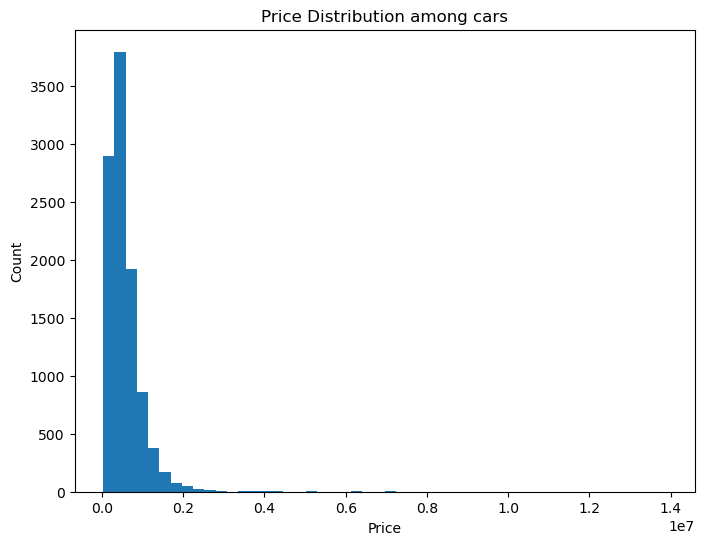

In [244]:
#Price Distribution
plt.figure(figsize = (8,6))
plt.hist(cars_data['Price'], bins = 50)
plt.title("Price Distribution among cars")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

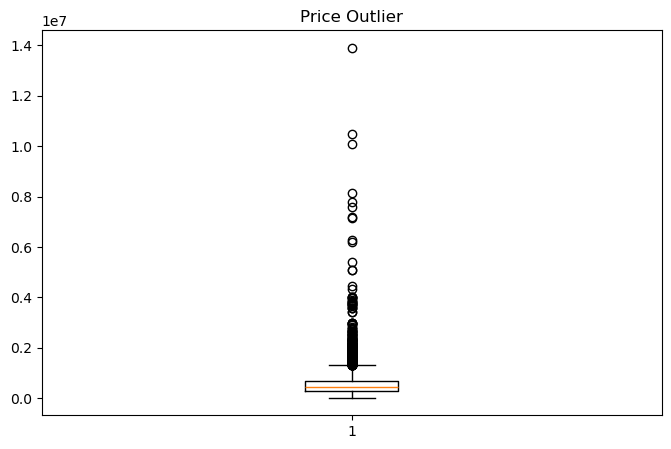

In [245]:
plt.figure(figsize = (8,5))
plt.boxplot(cars_data['Price'])
plt.title("Price Outlier")
plt.show()

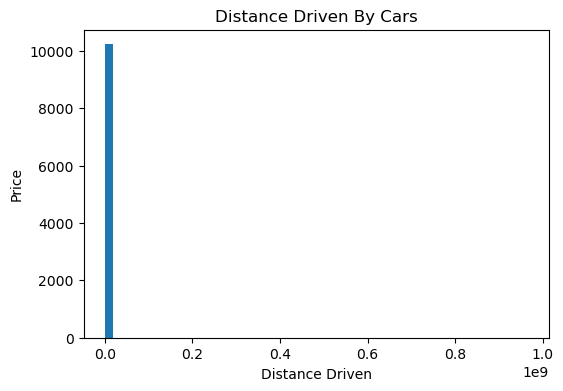

In [246]:
# Distance Driven 
plt.figure(figsize=(6,4))
plt.hist(cars_data['Distance Driven'],bins=50)
plt.title('Distance Driven By Cars')
plt.xlabel('Distance Driven')
plt.ylabel('Price')
plt.show()

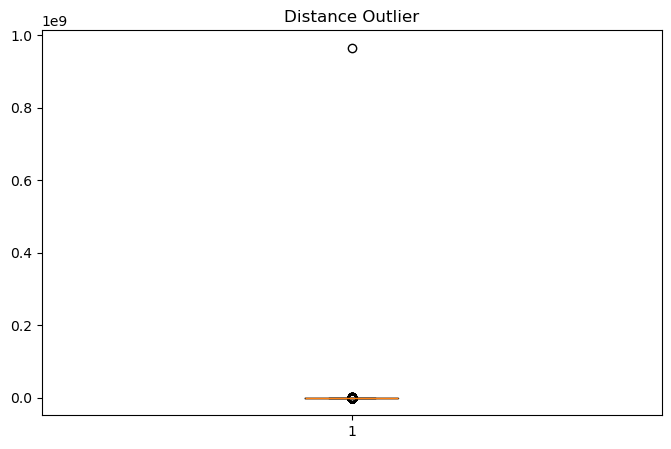

In [247]:
plt.figure(figsize = (8,5))
plt.boxplot(cars_data['Distance Driven'])
plt.title("Distance Outlier")
plt.show()

In [248]:
cars_data['Distance Driven'].max()

964935011

In [249]:
cars_data.sort_values("Distance Driven", ascending =False).head(20)[['Car Name', 'Company', 'Distance Driven', 'Price']]

,Car Name,Company,Distance Driven,Price
6857,KIA SONET,KIA,964935011,880000
5963,MG HECTOR,MG,1920000,900000
6240,MG HECTOR,MG,1760000,1150000
5613,Tata Indica Vista,Tata,1354000,90000
899,Maruti Eeco,Maruti,1300000,265000
9167,Hyundai i20,Hyundai,1010197,125000
9438,Chevrolet Cruze,Chevrolet,999999,314000
9757,Tata Harrier,Tata,915510,944999
1400,Tata Tiago,Tata,850000,520000
7824,Maruti Baleno,Maruti,780001,318000


In [250]:
cars_data= cars_data[cars_data["Distance Driven"] <= 500000]
cars_data

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price,Car Age,City
0,Tata TIGOR,Tata,2018,60000,Petrol,Manual,5737,325000,8,Agra
1,Maruti Alto 800,Maruti,2013,59183,Petrol,Manual,8084,172000,13,Agra
2,Mahindra Kuv100,Mahindra,2016,92583,Diesel,Manual,6683,254000,10,Agra
3,Hyundai Creta,Hyundai,2018,77164,Diesel,Manual,12871,658000,8,Agra
4,Mahindra Kuv100,Mahindra,2018,44360,Petrol,Manual,5649,320000,8,Agra
...,...,...,...,...,...,...,...,...,...,...
10222,Honda City,Honda,2015,76581,Petrol,Manual,11592,440000,11,Surat
10223,MG HECTOR,MG,2020,60401,Diesel,Manual,16266,950000,6,Surat
10224,Hyundai Eon,Hyundai,2017,11320,Petrol,Manual,4568,234000,9,Surat
10225,Maruti Alto,Maruti,2022,8104,Petrol,Manual,5086,288000,4,Surat


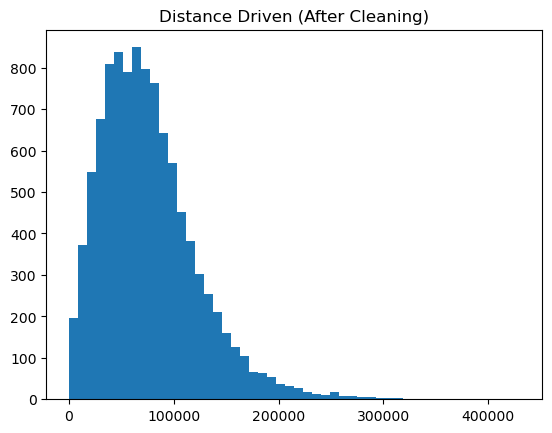

In [251]:
# km_driven after distribution 
plt.figure()
plt.hist(cars_data["Distance Driven"], bins=50)
plt.title("Distance Driven (After Cleaning)")
plt.show()

In [252]:
cars_data['Distance Driven'].max()

430000

In [253]:
cars_data.sort_values("Distance Driven", ascending =False).head(20)[['Car Name', 'Company', 'Distance Driven', 'Price']]

,Car Name,Company,Distance Driven,Price
8420,Mahindra TUV300,Mahindra,430000,530000
9215,Tata Hexa,Tata,395607,600000
8547,Hyundai i20 Active,Hyundai,350000,358000
5828,Mahindra XUV500,Mahindra,327672,385000
1239,Hyundai Creta,Hyundai,317475,520000
9447,Honda WR-V,Honda,312660,600000
6168,Toyota Innova,Toyota,312500,704000
6579,Nissan Sunny,Nissan,307369,132000
3932,Ford Ecosport,Ford,301913,375000
5318,Renault Kwid,Renault,300000,327000


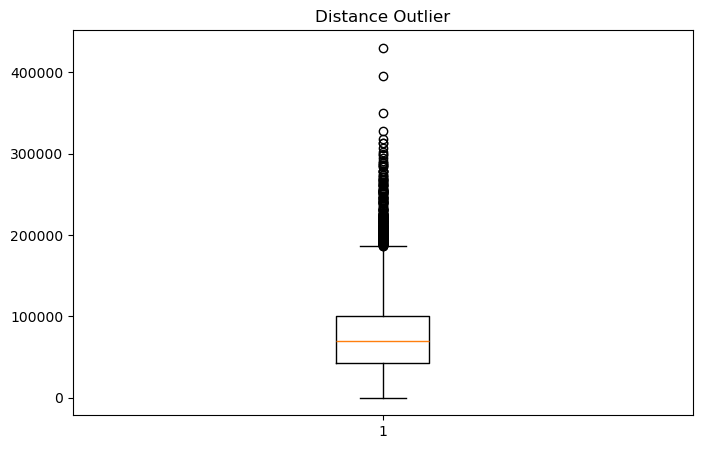

In [254]:
plt.figure(figsize = (8,5))
plt.boxplot(cars_data['Distance Driven'])
plt.title("Distance Outlier")
plt.show()

In [255]:
cars_data.to_csv('Cars24_data.csv',index=False)

## Exploratory Data Analysis (EDA)

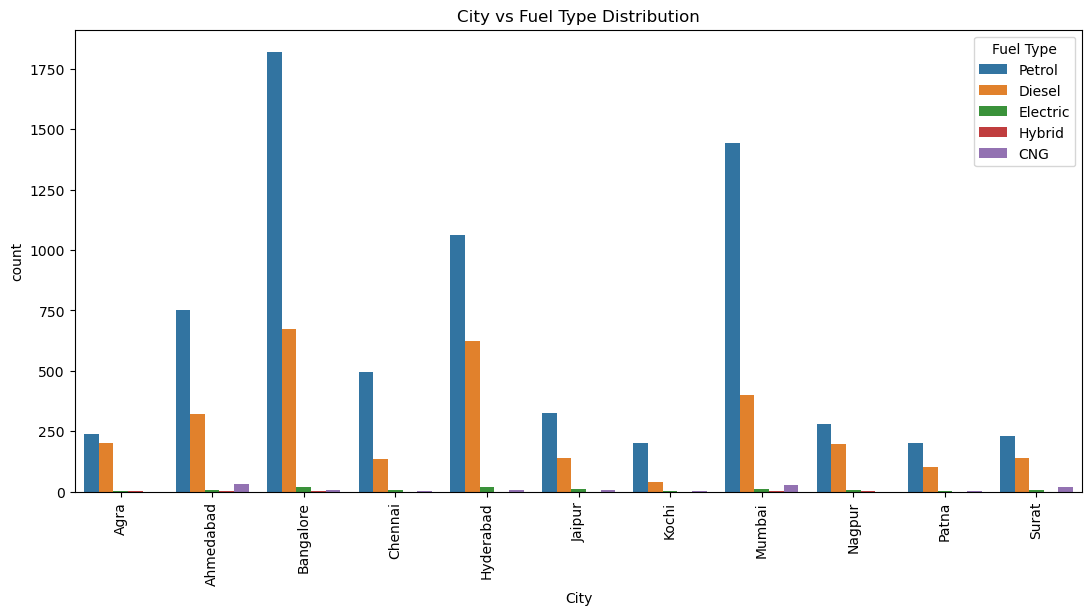

In [256]:
# City VS Fuel Type Distribution (CountPlot)
plt.figure(figsize=(13,6))
sns.countplot(data=cars_data,x='City',hue='Fuel Type')
plt.title('City vs Fuel Type Distribution')
plt.xticks(rotation=90)
plt.show()

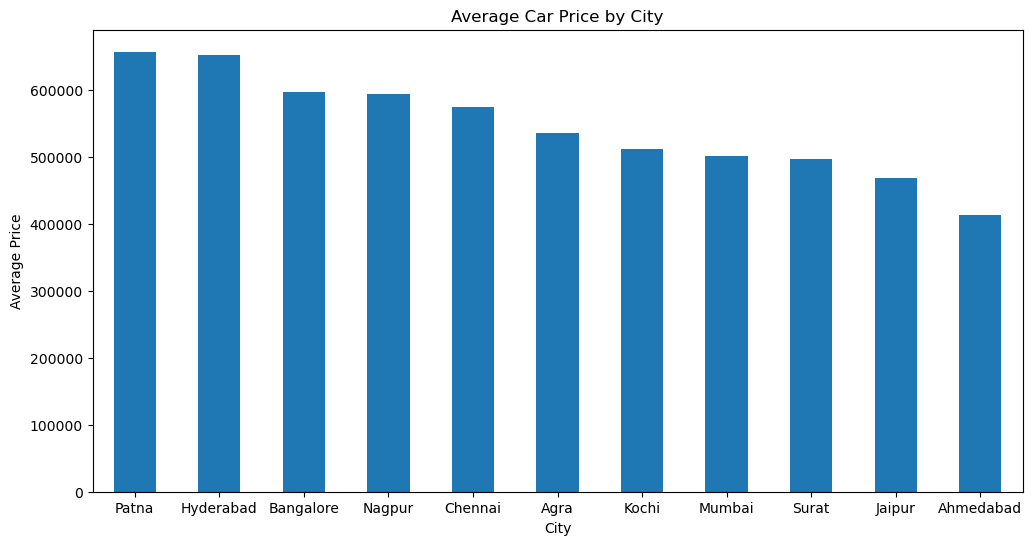

In [257]:
# Average Car Price by City 
avg_price = cars_data.groupby('City')['Price'].mean().sort_values(ascending=False)
plt.figure(figsize=(12,6))
avg_price.plot(kind='bar')
plt.title('Average Car Price by City')
plt.xlabel('City')
plt.ylabel('Average Price')
plt.xticks(rotation=0)
plt.show()


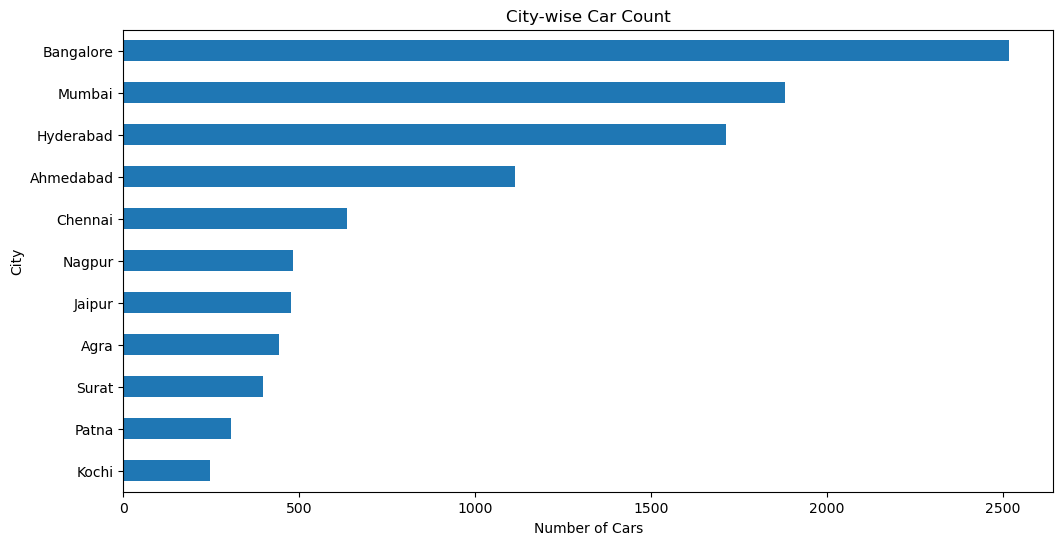

In [258]:
# City Wise Car Count
city_car_count = cars_data['City'].value_counts()
plt.figure(figsize=(12,6))
city_car_count.sort_values().plot(kind='barh')
plt.title('City-wise Car Count')
plt.xlabel('Number of Cars')
plt.ylabel('City')
plt.show()

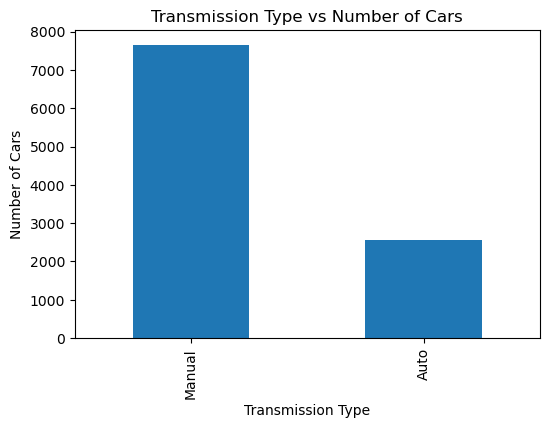

In [259]:
#Transmission Type Vs No of Cars
transmission_count = cars_data['Transmission Type'].value_counts()
plt.figure(figsize=(6,4))
transmission_count.plot(kind='bar')
plt.title('Transmission Type vs Number of Cars')
plt.xlabel('Transmission Type')
plt.ylabel('Number of Cars')
plt.show()